In [ ]:
pip install xarray netcdf4 rioxarray matplotlib pandas numpy

In [1]:
import xarray as xr
import matplotlib.pyplot as plt

### Uploading the files and printing the file details and variable details

In [2]:
grace_gw = xr.open_dataset(r"D:\IITB Mini_projects\GNR644\GroundWater\GRACE_raw\PENINSULAR_INDIA_GRACE_0p25deg.nc")
print(grace_gw)

<xarray.Dataset> Size: 9MB
Dimensions:        (time: 240, lat: 67, lon: 73)
Coordinates:
  * time           (time) datetime64[ns] 2kB 2002-04-17T12:00:00 ... 2024-12-...
  * lat            (lat) float64 536B 8.25 8.5 8.75 9.0 ... 24.25 24.5 24.75
  * lon            (lon) float64 584B 72.75 73.0 73.25 73.5 ... 90.25 90.5 90.75
    spatial_ref    int64 8B ...
Data variables:
    WGS84          int64 8B ...
    lwe_thickness  (time, lat, lon) float64 9MB ...


In [3]:
grace_gw_var = grace_gw['lwe_thickness']
print("GroundWater (GRACE):", grace_gw.data_vars)
print(grace_gw_var)

GroundWater (GRACE): Data variables:
    WGS84          int64 8B ...
    lwe_thickness  (time, lat, lon) float64 9MB ...
<xarray.DataArray 'lwe_thickness' (time: 240, lat: 67, lon: 73)> Size: 9MB
[1173840 values with dtype=float64]
Coordinates:
  * time         (time) datetime64[ns] 2kB 2002-04-17T12:00:00 ... 2024-12-16...
  * lat          (lat) float64 536B 8.25 8.5 8.75 9.0 ... 24.0 24.25 24.5 24.75
  * lon          (lon) float64 584B 72.75 73.0 73.25 73.5 ... 90.25 90.5 90.75
    spatial_ref  int64 8B ...
Attributes:
    units:          cm
    long_name:      Liquid_Water_Equivalent_Thickness
    standard_name:  Liquid_Water_Equivalent_Thickness
    valid_min:      -2217.985047393996
    valid_max:      1169.1183758129675
    comment:        Coastline Resolution Improvement (CRI) filter is applied
    grid_mapping:   WGS84


### Plotting the Time Series map using the mean of Peninsular Basin (GRACE GW)

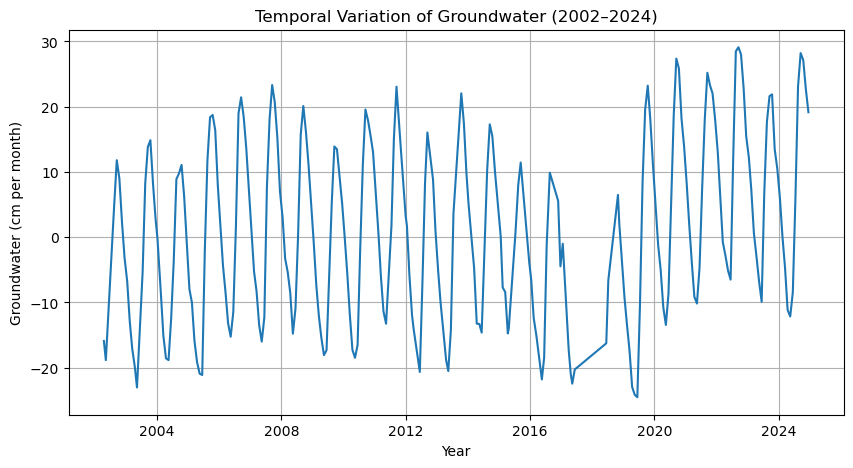

In [7]:
grace_gw_ts = grace_gw_var.mean(dim=['lat','lon'])
plt.figure(figsize=(10,5))

grace_gw_ts.plot(label='grace (Groundwater)')

plt.title("Temporal Variation of Groundwater (2002–2024)")
plt.xlabel("Year")
plt.ylabel("Groundwater (cm per month)")
plt.grid(True)

plt.show()

### Grouping the mean by Month

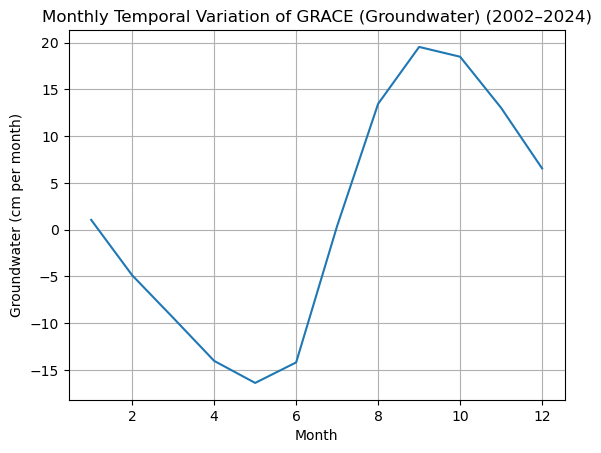

In [9]:
grace_gw_season = grace_gw_ts.groupby('time.month').mean()
grace_gw_season.plot(label='grace (Groundwater)')
plt.title("Monthly Temporal Variation of GRACE (Groundwater) (2002–2024)")
plt.xlabel("Month")
plt.ylabel("Groundwater (cm per month)")
plt.grid(True)

### Trend Analysis

In [10]:
import numpy as np
from scipy.stats import linregress

time_grace_gw = np.arange(len(grace_gw_ts))

slope, intercept, r, p, std = linregress(time_grace_gw, grace_gw_ts)

print("Trend slope:", slope)
print("p-value:", p)

Trend slope: 0.041909746266646515
p-value: 0.0010031642201731696


#### Since the slope is greater than 0, it is increasing

### Pixel wise Trend using MK Test (not like previous one where we perfrom MK Test month wise, here we perform MK Test Overall)

In [11]:
def trend_calc(y):
    x = np.arange(len(y))
    slope, _, _, _, _ = linregress(x, y)
    return slope

Text(0.5, 1.0, 'Mann Kendall Trend Analysis for GRACE (Groundwater) from 2002 to 2024')

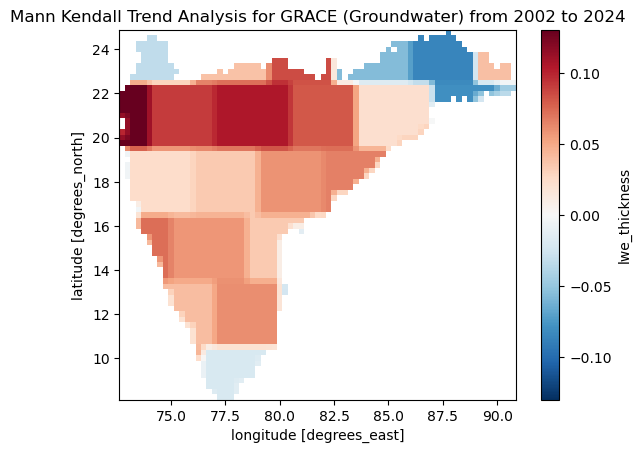

In [15]:
et_trend = xr.apply_ufunc(
    trend_calc,
    grace_gw_var,
    input_core_dims=[['time']],
    vectorize=True
)

et_trend.plot()
plt.title("Mann Kendall Trend Analysis for GRACE (Groundwater) from 2002 to 2024")

### Anomaly to find Drought years

Text(0.5, 1.0, 'Anomaly TSA Plot for GRACE (Groundwater)')

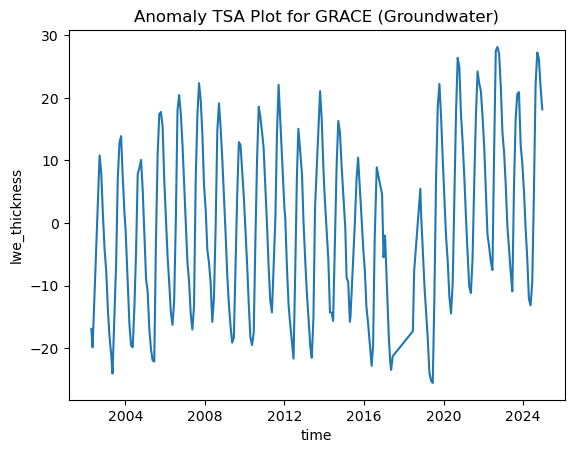

In [17]:
grace_gw_mean = grace_gw_ts.mean()
grace_gw_anomaly = grace_gw_ts - grace_gw_mean

grace_gw_anomaly.plot()
plt.title("Anomaly TSA Plot for GRACE (Groundwater)") 